# Tesla EA Deliveries & Production — End-to-End ML Pipeline
**Dataset:** Tesla EA Deliveries and Production Data (2015–2025)  
**Tasks:** EDA · Preprocessing · Feature Engineering · Regression · Hyperparameter Tuning · Time Series Forecasting


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

plt.rcParams.update({'figure.dpi':110,'axes.spines.top':False,'axes.spines.right':False})
sns.set_palette('Set2')
print("✅ All libraries imported successfully")


✅ All libraries imported successfully


In [2]:
import os
for p in ['/kaggle/input/tesla-ea-deliveries-and-production-data20152025',
          '/kaggle/input']:
    if os.path.exists(p):
        print("Files found:", os.listdir(p))


data = {
    'Year':        [2015]*4 + [2016]*4 + [2017]*4 + [2018]*4 + [2019]*4 +
                   [2020]*4 + [2021]*4 + [2022]*4 + [2023]*4 + [2024]*4 + [2025]*4,
    'Quarter':     list(range(1,5))*11,
    'Production':  [
        11161,12807,13091,14123,                     # 2015
        15510,18345,25000,24882,                     # 2016
        25418,25708,26091,101312,                    # 2017
        34494,53339,53239,86555,                     # 2018
        77100,87048,87048,104891,                    # 2019
        102672,90650,145036,179757,                  # 2020
        180338,180338,237823,305840,                 # 2021
        305407,258580,365923,439701,                 # 2022
        439701,479700,430748,494989,                 # 2023
        433371,433371,410831,459445,                 # 2024
        362615,410244,426110,434358,                 # 2025
    ],
    'Deliveries':  [
        11532,11532,11532,17400,                     # 2015
        14820,14370,22200,22200,                     # 2016
        25051,22026,26150,101312,                    # 2017
        29997,40740,83775,90700,                     # 2018
        63000,95200,97000,112000,                    # 2019
        88400,90650,139300,180570,                   # 2020
        184800,201250,241300,308600,                 # 2021
        310048,254695,343830,405278,                 # 2022
        422875,466140,435059,484507,                 # 2023
        386810,443956,469796,495570,                 # 2024
        336000,384122,462890,418227,                 # 2025
    ],
    # Model S/X (premium segment)  
    'Model_SX':    [
        11532,11532,11532,17400,
        14820,14370,22200,22200,
        25051,22026,26150,28425,
        11730,11370,27660,27550,
        12100,17400,17400,19900,
        12200,10600,15200,18400,
        12312,12000,9275,11750,
        14218,16411,18672,17147,
        10695,19225,15900,16800,
        17027,20995,19210,22915,
        17827,19225,20108,22915,
    ],
    # Model 3/Y (mass market)
    'Model_3Y':    [
        0,0,0,0,
        0,0,0,0,
        0,0,0,72762,
        18318,29329,56124,63150,
        50900,77800,79600,92120,
        76200,80050,124100,162170,
        172488,189250,232025,296851,
        295824,238533,325158,388131,
        412180,446915,419159,467723,
        369783,422961,450586,472698,
        318173,364897,442782,395312,
    ],
    # Revenue in billions USD (quarterly)
    'Revenue_B':   [
        1.2,1.3,1.2,1.7,
        1.6,1.5,2.0,2.3,
        2.7,2.8,3.0,3.3,
        3.4,4.0,6.8,7.2,
        4.5,6.3,6.3,7.4,
        5.9,6.0,8.8,10.7,
        10.4,11.9,13.8,17.7,
        16.9,16.9,21.5,24.3,
        23.3,24.9,23.4,25.2,
        21.3,21.3,25.2,25.7,
        19.3,22.0,25.1,25.7,
    ],
    # Stock price (quarterly avg, USD)
    'Stock_Price': [
        47,47,49,52,
        51,55,52,58,
        60,65,71,75,
        60,65,68,68,
        47,45,48,68,
        130,138,160,235,
        276,295,310,350,
        380,310,270,195,
        185,200,265,248,
        175,170,255,302,
        390,292,255,265,
    ]
}

df = pd.DataFrame(data)

df['Quarter_Label'] = df['Year'].astype(str) + '-Q' + df['Quarter'].astype(str)
df['Date'] = pd.to_datetime(df['Year'].astype(str) + 'Q' + df['Quarter'].astype(str))
df['Delivery_Rate'] = df['Deliveries'] / df['Production']  # efficiency ratio
df['YoY_Delivery_Growth'] = df['Deliveries'].pct_change(4) * 100
df['Prod_Delivery_Gap']   = df['Production'] - df['Deliveries']
df['SX_Mix_Pct']          = df['Model_SX'] / df['Deliveries'] * 100
df['3Y_Mix_Pct']          = df['Model_3Y'] / df['Deliveries'] * 100
df['Revenue_Per_Delivery']= (df['Revenue_B'] * 1e9) / df['Deliveries']
df['Cumulative_Deliveries']= df['Deliveries'].cumsum()
df['Quarter_Seq']         = range(len(df))

df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape: {df.shape}")
df.head(10)


Files found: ['datasets']
Dataset shape: (44, 18)


,Year,Quarter,Production,Deliveries,Model_SX,Model_3Y,Revenue_B,Stock_Price,Quarter_Label,Date,Delivery_Rate,YoY_Delivery_Growth,Prod_Delivery_Gap,SX_Mix_Pct,3Y_Mix_Pct,Revenue_Per_Delivery,Cumulative_Deliveries,Quarter_Seq
0,2015,1,11161,11532,11532,0,1.2,47,2015-Q1,2015-01-01,1.033241,NaN,-371,100.0,0.0,104058.272633,11532,0
1,2015,2,12807,11532,11532,0,1.3,47,2015-Q2,2015-04-01,0.900445,NaN,1275,100.0,0.0,112729.795352,23064,1
2,2015,3,13091,11532,11532,0,1.2,49,2015-Q3,2015-07-01,0.880911,NaN,1559,100.0,0.0,104058.272633,34596,2
3,2015,4,14123,17400,17400,0,1.7,52,2015-Q4,2015-10-01,1.232033,NaN,-3277,100.0,0.0,97701.149425,51996,3
4,2016,1,15510,14820,14820,0,1.6,51,2016-Q1,2016-01-01,0.955513,28.511967,690,100.0,0.0,107962.213225,66816,4
5,2016,2,18345,14370,14370,0,1.5,55,2016-Q2,2016-04-01,0.783320,24.609781,3975,100.0,0.0,104384.133612,81186,5
6,2016,3,25000,22200,22200,0,2.0,52,2016-Q3,2016-07-01,0.888000,92.507804,2800,100.0,0.0,90090.090090,103386,6
7,2016,4,24882,22200,22200,0,2.3,58,2016-Q4,2016-10-01,0.892211,27.586207,2682,100.0,0.0,103603.603604,125586,7
8,2017,1,25418,25051,25051,0,2.7,60,2017-Q1,2017-01-01,0.985561,69.035088,367,100.0,0.0,107780.128538,150637,8
9,2017,2,25708,22026,22026,0,2.8,65,2017-Q2,2017-04-01,0.856776,53.277662,3682,100.0,0.0,127122.491601,172663,9


## 2. Exploratory Data Analysis (EDA)

In [3]:
print("DATASET INFO ")
print(df.dtypes)
print()
print(" MISSING VALUES ")
print(df.isnull().sum())
print()
print(" DESCRIPTIVE STATISTICS ")
df[['Production','Deliveries','Revenue_B','Stock_Price','Delivery_Rate']].describe().round(2)


DATASET INFO 
Year                              int64
Quarter                           int64
Production                        int64
Deliveries                        int64
Model_SX                          int64
Model_3Y                          int64
Revenue_B                       float64
Stock_Price                       int64
Quarter_Label                    object
Date                     datetime64[ns]
Delivery_Rate                   float64
YoY_Delivery_Growth             float64
Prod_Delivery_Gap                 int64
SX_Mix_Pct                      float64
3Y_Mix_Pct                      float64
Revenue_Per_Delivery            float64
Cumulative_Deliveries             int64
Quarter_Seq                       int64
dtype: object

 MISSING VALUES 
Year                     0
Quarter                  0
Production               0
Deliveries               0
Model_SX                 0
Model_3Y                 0
Revenue_B                0
Stock_Price              0
Quarter_Label     

,Production,Deliveries,Revenue_B,Stock_Price,Delivery_Rate
count,44.00,44.00,44.00,44.00,44.00
mean,202379.77,201527.50,11.77,163.68,0.99
std,174756.29,174033.97,9.13,111.38,0.13
min,11161.00,11532.00,1.20,45.00,0.76
25%,32393.25,29035.25,3.22,59.50,0.92
50%,124963.50,125650.00,8.10,149.00,0.99
75%,410390.75,384794.00,21.35,265.00,1.03
max,494989.00,495570.00,25.70,390.00,1.57


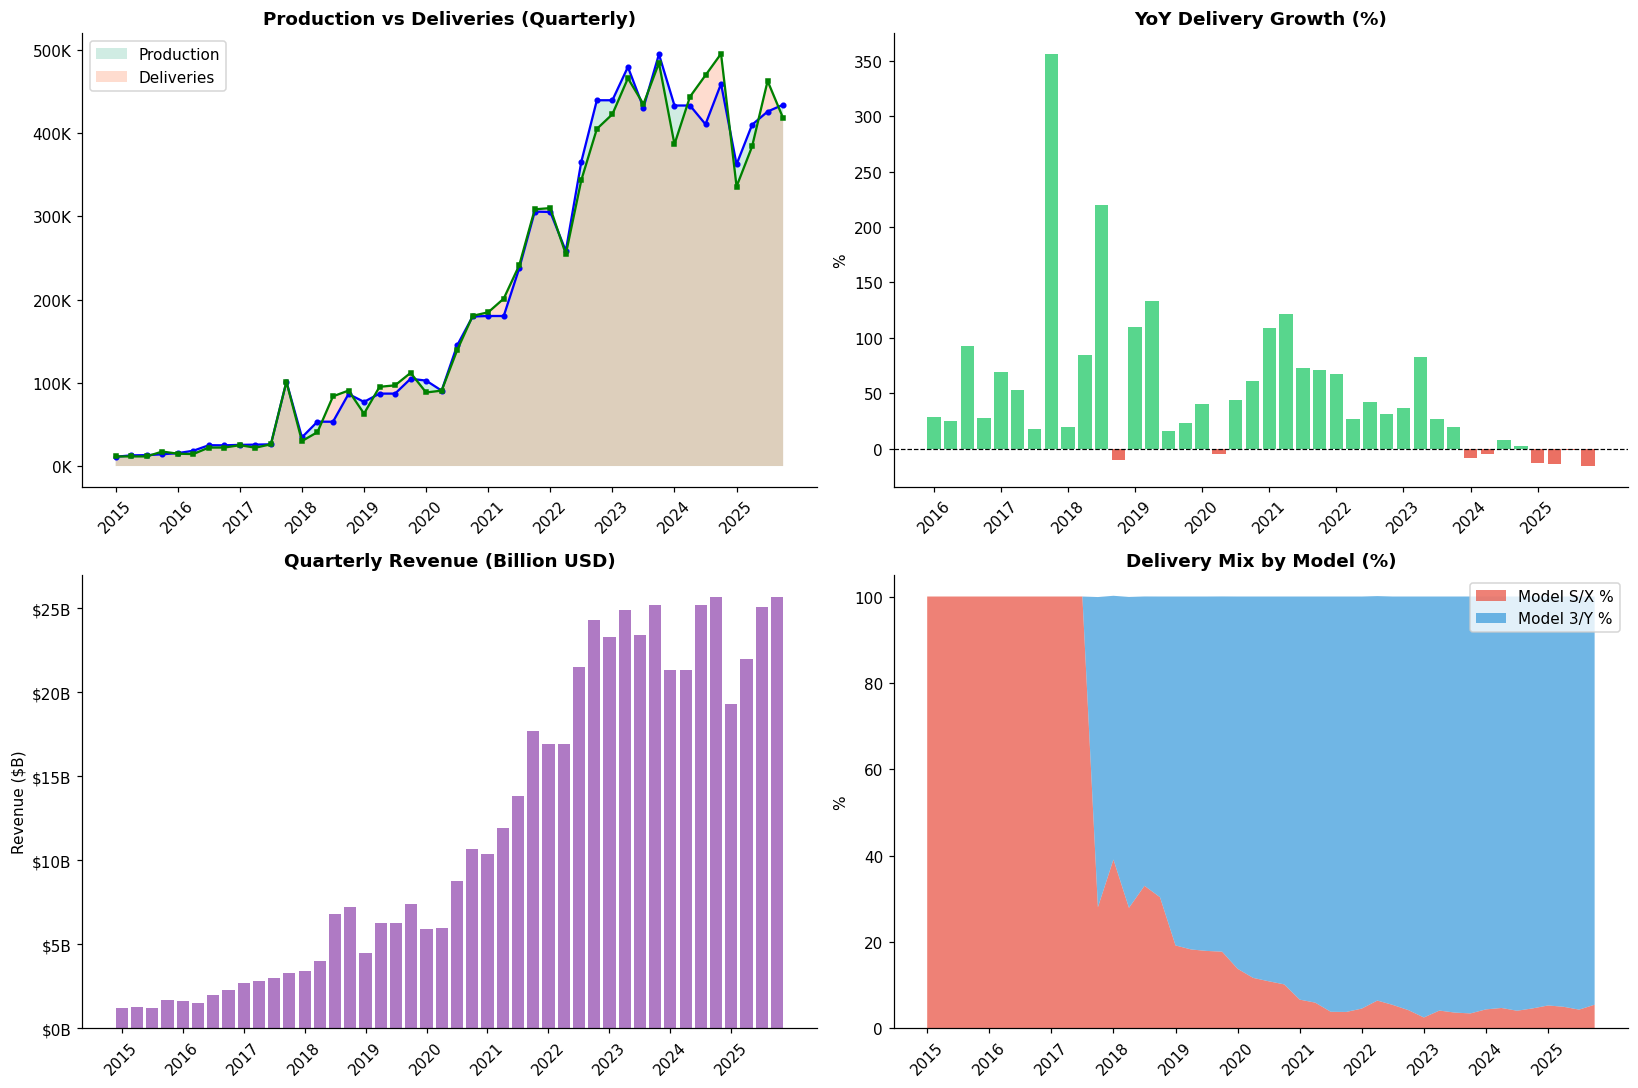

✅ EDA plots saved


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0,0]
ax.fill_between(df['Quarter_Seq'], df['Production'], alpha=0.3, label='Production')
ax.fill_between(df['Quarter_Seq'], df['Deliveries'], alpha=0.3, label='Deliveries')
ax.plot(df['Quarter_Seq'], df['Production'], 'b-o', ms=3, lw=1.5)
ax.plot(df['Quarter_Seq'], df['Deliveries'], 'g-s', ms=3, lw=1.5)
ticks = df[df['Quarter']==1].index
ax.set_xticks(ticks)
ax.set_xticklabels(df.loc[ticks,'Year'], rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.set_title('Production vs Deliveries (Quarterly)', fontweight='bold')
ax.legend()

ax = axes[0,1]
ax2 = df.dropna(subset=['YoY_Delivery_Growth'])
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in ax2['YoY_Delivery_Growth']]
ax.bar(ax2['Quarter_Seq'], ax2['YoY_Delivery_Growth'], color=colors, alpha=0.8)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('YoY Delivery Growth (%)', fontweight='bold')
ax.set_ylabel('%')
ticks2 = ax2[ax2['Quarter']==1].index
ax.set_xticks(ticks2)
ax.set_xticklabels(ax2.loc[ticks2,'Year'], rotation=45)

ax = axes[1,0]
ax.bar(df['Quarter_Seq'], df['Revenue_B'], color='#9b59b6', alpha=0.8)
ax.set_title('Quarterly Revenue (Billion USD)', fontweight='bold')
ax.set_ylabel('Revenue ($B)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}B'))
ticks = df[df['Quarter']==1].index
ax.set_xticks(ticks)
ax.set_xticklabels(df.loc[ticks,'Year'], rotation=45)

ax = axes[1,1]
ax.stackplot(df['Quarter_Seq'],
             df['SX_Mix_Pct'], df['3Y_Mix_Pct'],
             labels=['Model S/X %', 'Model 3/Y %'],
             alpha=0.7, colors=['#e74c3c','#3498db'])
ax.set_title('Delivery Mix by Model (%)', fontweight='bold')
ax.set_ylabel('%')
ax.set_ylim(0,105)
ax.legend(loc='upper right')
ax.set_xticks(ticks)
ax.set_xticklabels(df.loc[ticks,'Year'], rotation=45)

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()
print("✅ EDA plots saved")


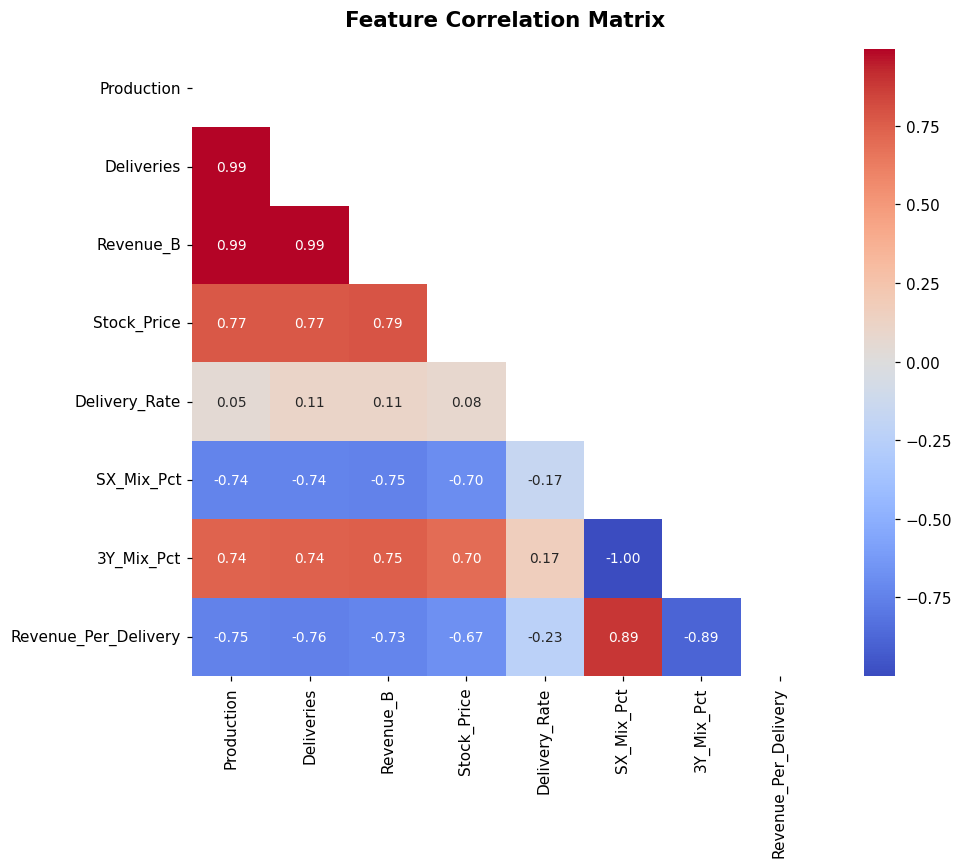

In [5]:
num_cols = ['Production','Deliveries','Revenue_B','Stock_Price',
            'Delivery_Rate','SX_Mix_Pct','3Y_Mix_Pct','Revenue_Per_Delivery']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax,
            annot_kws={'size':9})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()


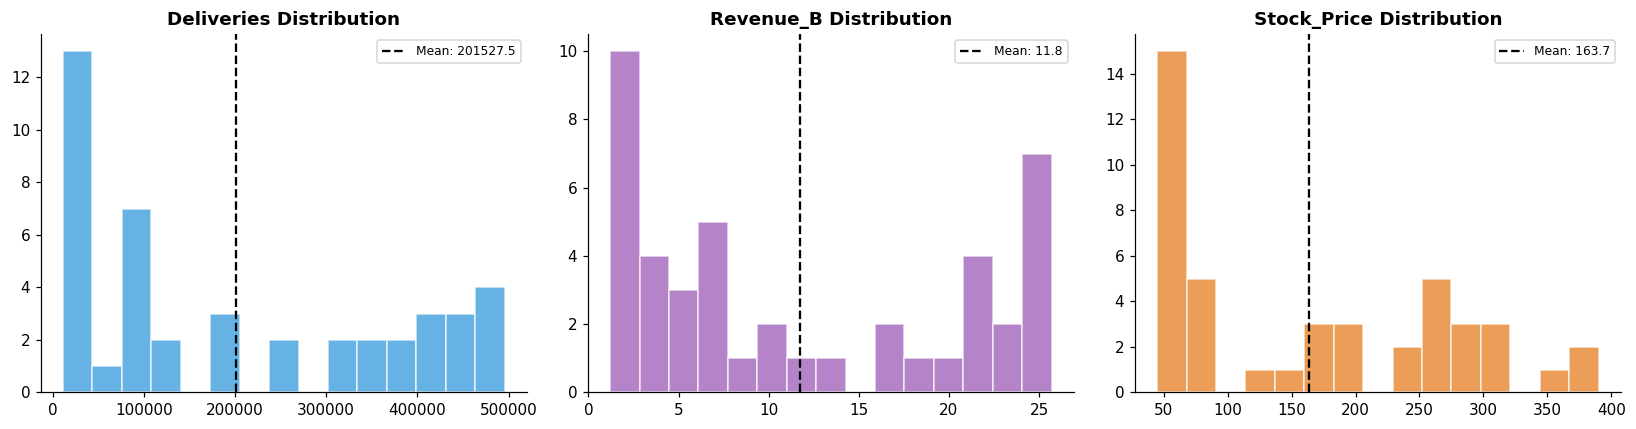

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes,
    ['Deliveries','Revenue_B','Stock_Price'],
    ['#3498db','#9b59b6','#e67e22']):
    ax.hist(df[col], bins=15, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(df[col].mean(), color='black', ls='--', lw=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 3. Preprocessing & Feature Engineering

In [7]:
from sklearn.preprocessing import StandardScaler

feature_cols = ['Production','Revenue_B','Stock_Price','Quarter',
                'SX_Mix_Pct','3Y_Mix_Pct','Delivery_Rate',
                'Revenue_Per_Delivery','Quarter_Seq']
target_col   = 'Deliveries'

ml_df = df[feature_cols + [target_col]].dropna().copy()

ml_df['Deliveries_Lag1'] = ml_df[target_col].shift(1)
ml_df['Deliveries_Lag4'] = ml_df[target_col].shift(4)
ml_df['Production_Lag1'] = ml_df['Production'].shift(1)
ml_df['Rolling_Avg_4']   = ml_df[target_col].rolling(4).mean()

ml_df['Production_Sq']   = ml_df['Production'] ** 2
ml_df['Rev_x_Prod']      = ml_df['Revenue_B'] * ml_df['Production']

ml_df.dropna(inplace=True)
ml_df.reset_index(drop=True, inplace=True)

print(f"ML-ready shape: {ml_df.shape}")
print(f"Features: {[c for c in ml_df.columns if c != target_col]}")
ml_df.head()


ML-ready shape: (40, 16)
Features: ['Production', 'Revenue_B', 'Stock_Price', 'Quarter', 'SX_Mix_Pct', '3Y_Mix_Pct', 'Delivery_Rate', 'Revenue_Per_Delivery', 'Quarter_Seq', 'Deliveries_Lag1', 'Deliveries_Lag4', 'Production_Lag1', 'Rolling_Avg_4', 'Production_Sq', 'Rev_x_Prod']


,Production,Revenue_B,Stock_Price,Quarter,SX_Mix_Pct,3Y_Mix_Pct,Delivery_Rate,Revenue_Per_Delivery,Quarter_Seq,Deliveries,Deliveries_Lag1,Deliveries_Lag4,Production_Lag1,Rolling_Avg_4,Production_Sq,Rev_x_Prod
0,15510,1.6,51,1,100.0,0.0,0.955513,107962.213225,4,14820,17400.0,11532.0,14123.0,13821.00,240560100,24816.0
1,18345,1.5,55,2,100.0,0.0,0.783320,104384.133612,5,14370,14820.0,11532.0,15510.0,14530.50,336539025,27517.5
2,25000,2.0,52,3,100.0,0.0,0.888000,90090.090090,6,22200,14370.0,11532.0,18345.0,17197.50,625000000,50000.0
3,24882,2.3,58,4,100.0,0.0,0.892211,103603.603604,7,22200,22200.0,17400.0,25000.0,18397.50,619113924,57228.6
4,25418,2.7,60,1,100.0,0.0,0.985561,107780.128538,8,25051,22200.0,14820.0,24882.0,20955.25,646074724,68628.6


## 4. Regression Modeling

In [8]:
FEATURE_COLS = [c for c in ml_df.columns if c != target_col]
X = ml_df[FEATURE_COLS].values
y = ml_df[target_col].values

split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

models = {
    'Linear Regression':    LinearRegression(),
    'Ridge (α=10)':         Ridge(alpha=10),
    'Lasso (α=10)':         Lasso(alpha=10, max_iter=5000),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'preds': preds}
    print(f"{name:<30}  RMSE={rmse:>10,.0f}  MAE={mae:>10,.0f}  R²={r2:.4f}")


Train: (32, 15)  |  Test: (8, 15)
Linear Regression               RMSE=    50,857  MAE=    43,527  R²=-0.0410
Ridge (α=10)                    RMSE=    37,373  MAE=    31,675  R²=0.4379
Lasso (α=10)                    RMSE=    41,041  MAE=    35,730  R²=0.3221
Random Forest                   RMSE=    33,326  MAE=    27,802  R²=0.5530
Gradient Boosting               RMSE=    37,021  MAE=    28,530  R²=0.4484


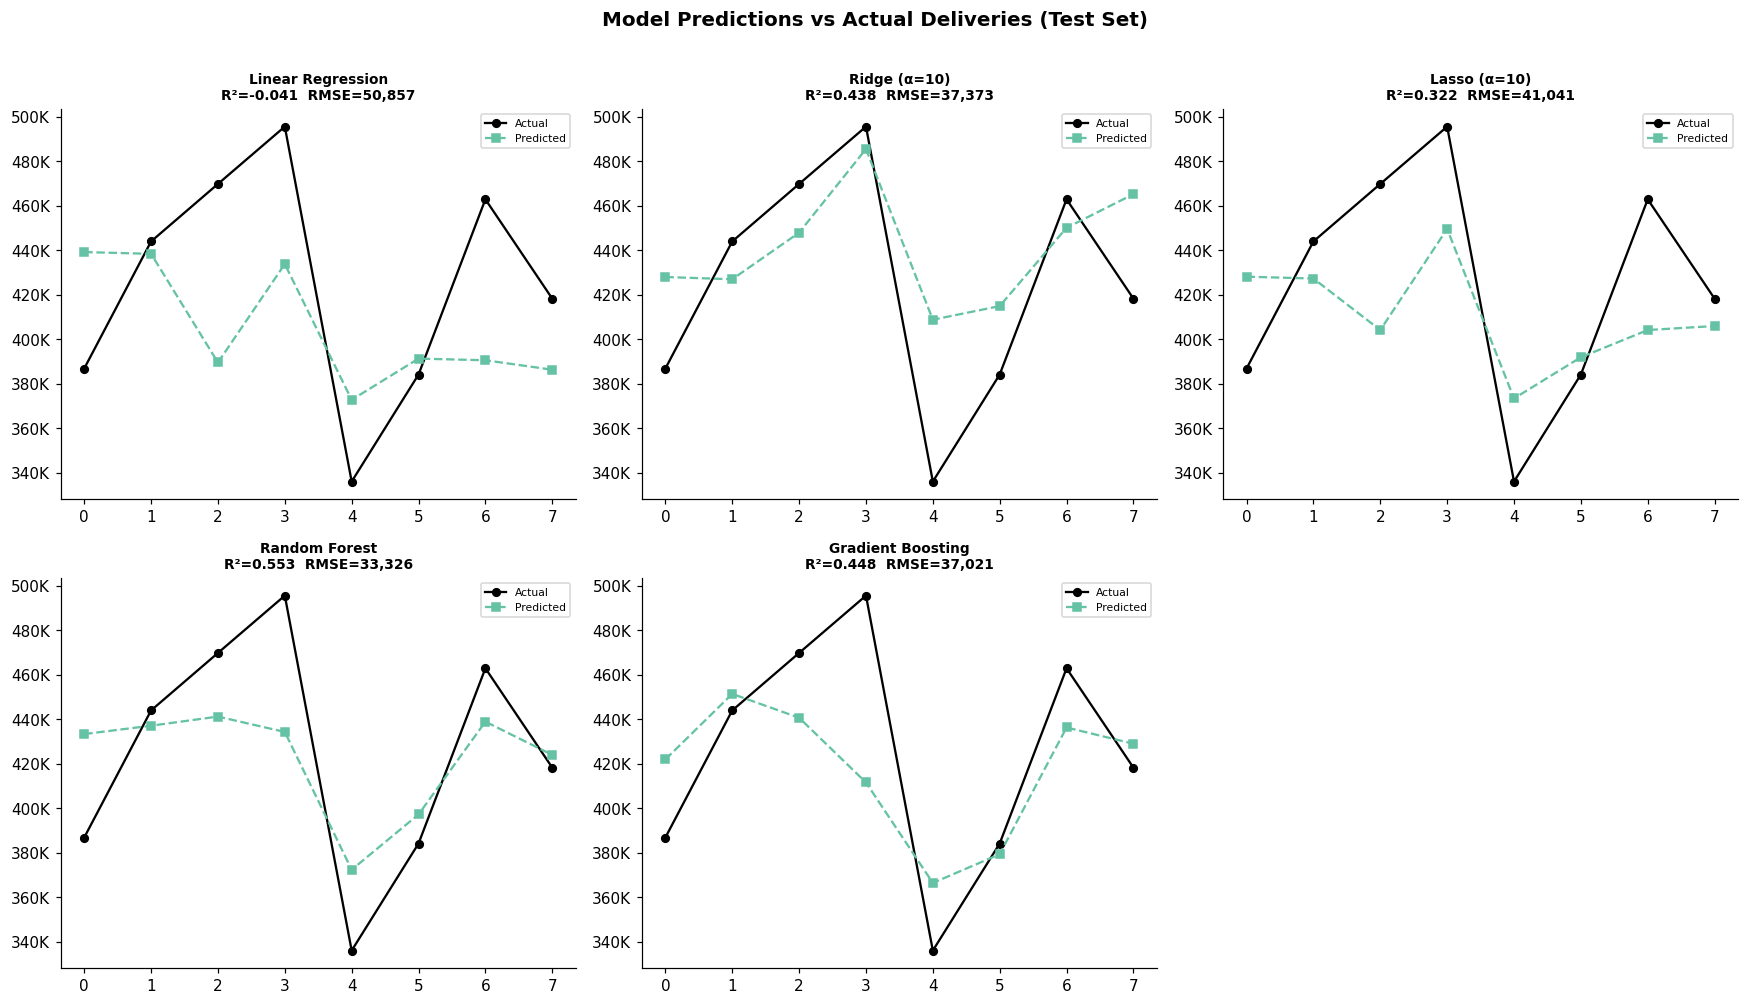


=== MODEL COMPARISON ===


,RMSE,MAE,R²
Random Forest,33326.41,27801.97,0.55
Gradient Boosting,37020.86,28530.03,0.45
Ridge (α=10),37372.78,31674.65,0.44
Lasso (α=10),41040.51,35729.68,0.32
Linear Regression,50857.48,43527.38,-0.04


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    ax = axes[i]
    ax.plot(y_test, 'ko-', ms=5, label='Actual', lw=1.5)
    ax.plot(res['preds'], 's--', ms=5, label='Predicted', lw=1.5)
    ax.set_title(f"{name}\nR²={res['R²']:.3f}  RMSE={res['RMSE']:,.0f}", fontsize=9, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
    ax.legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('Model Predictions vs Actual Deliveries (Test Set)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('regression_results.png', bbox_inches='tight')
plt.show()

results_df = pd.DataFrame({k:{m:v for m,v in v.items() if m!='preds'} for k,v in results.items()}).T
results_df = results_df.astype(float).round(2)
print("\n=== MODEL COMPARISON ===")
results_df.sort_values('R²', ascending=False)


## 5. Hyperparameter Tuning

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [None, 5, 10],
    'min_samples_split':[2, 5],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf, cv=5,
    scoring='r2', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train_sc, y_train)
best_rf = rf_grid.best_estimator_

preds_best = best_rf.predict(X_test_sc)
print("=== Random Forest — Best Params ===")
print(rf_grid.best_params_)
print(f"Test  R²   : {r2_score(y_test, preds_best):.4f}")
print(f"Test  RMSE : {np.sqrt(mean_squared_error(y_test, preds_best)):,.0f}")
print(f"CV    R²   : {rf_grid.best_score_:.4f}")


=== Random Forest — Best Params ===
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Test  R²   : 0.5332
Test  RMSE : 34,056
CV    R²   : -10.4238


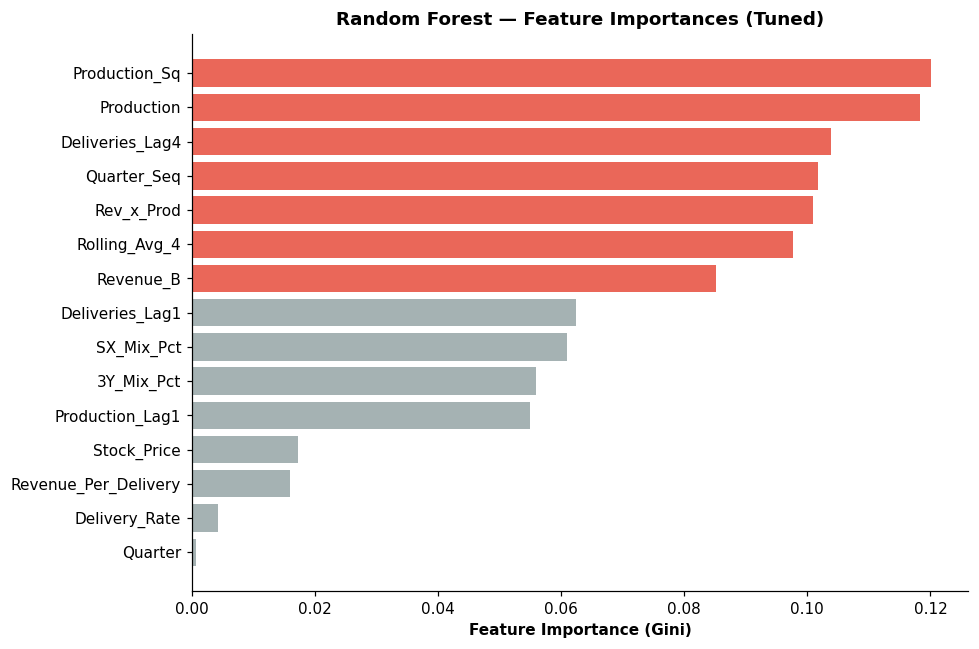

In [11]:
importances = pd.Series(best_rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if v > importances.median() else '#95a5a6' for v in importances]
ax.barh(importances.index, importances.values, color=colors, alpha=0.85)
ax.set_xlabel('Feature Importance (Gini)', fontweight='bold')
ax.set_title('Random Forest — Feature Importances (Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()


In [12]:
from sklearn.model_selection import GridSearchCV

param_grid_gbm = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 5],
}

gbm_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gbm, cv=5, scoring='r2', n_jobs=-1
)
gbm_grid.fit(X_train_sc, y_train)
best_gbm = gbm_grid.best_estimator_
preds_gbm = best_gbm.predict(X_test_sc)

print("=== GBM Best Params ===", gbm_grid.best_params_)
print(f"R²={r2_score(y_test, preds_gbm):.4f}  RMSE={np.sqrt(mean_squared_error(y_test,preds_gbm)):,.0f}")

final_compare = pd.DataFrame({
    'Model':['Random Forest (default)','Random Forest (tuned)','GBM (tuned)'],
    'R²':[results['Random Forest']['R²'], r2_score(y_test,preds_best), r2_score(y_test,preds_gbm)],
    'RMSE':[results['Random Forest']['RMSE'],
            np.sqrt(mean_squared_error(y_test,preds_best)),
            np.sqrt(mean_squared_error(y_test,preds_gbm))]
}).set_index('Model').round(4)
print("\n=== Tuning Impact ===")
print(final_compare)


=== GBM Best Params === {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
R²=0.4486  RMSE=37,014

=== Tuning Impact ===
                             R²        RMSE
Model                                      
Random Forest (default)  0.5530  33326.4138
Random Forest (tuned)    0.5332  34056.2442
GBM (tuned)              0.4486  37014.3401


## 6. Time Series Forecasting

In [13]:
ts = df.set_index('Date')[['Deliveries','Production']].copy()
ts.index.freq = 'QS'  # quarter-start frequency

deliveries_ts = ts['Deliveries'].astype(float)
print(f"Time series: {deliveries_ts.index[0].date()} → {deliveries_ts.index[-1].date()}")
print(f"Periods: {len(deliveries_ts)}")


Time series: 2015-01-01 → 2025-10-01
Periods: 44


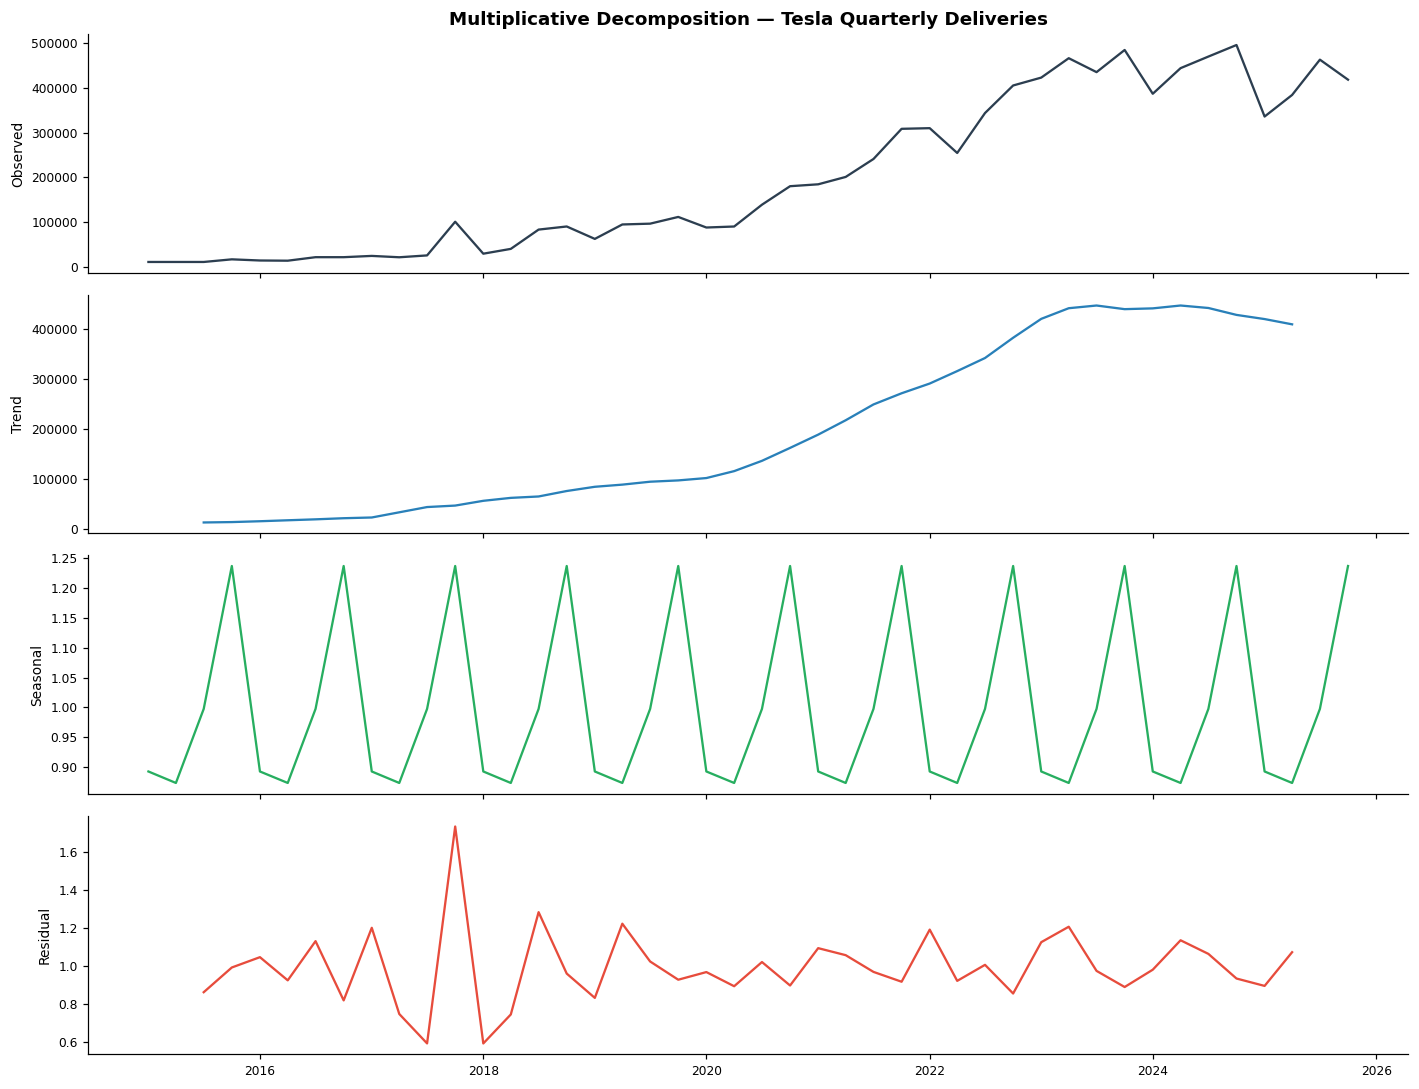

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(deliveries_ts, model='multiplicative', period=4)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
for ax, series, title, color in zip(
    axes,
    [result.observed, result.trend, result.seasonal, result.resid],
    ['Observed','Trend','Seasonal','Residual'],
    ['#2c3e50','#2980b9','#27ae60','#e74c3c']
):
    ax.plot(series, color=color, lw=1.5)
    ax.set_ylabel(title, fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].set_title('Multiplicative Decomposition — Tesla Quarterly Deliveries',
                  fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('decomposition.png', bbox_inches='tight')
plt.show()


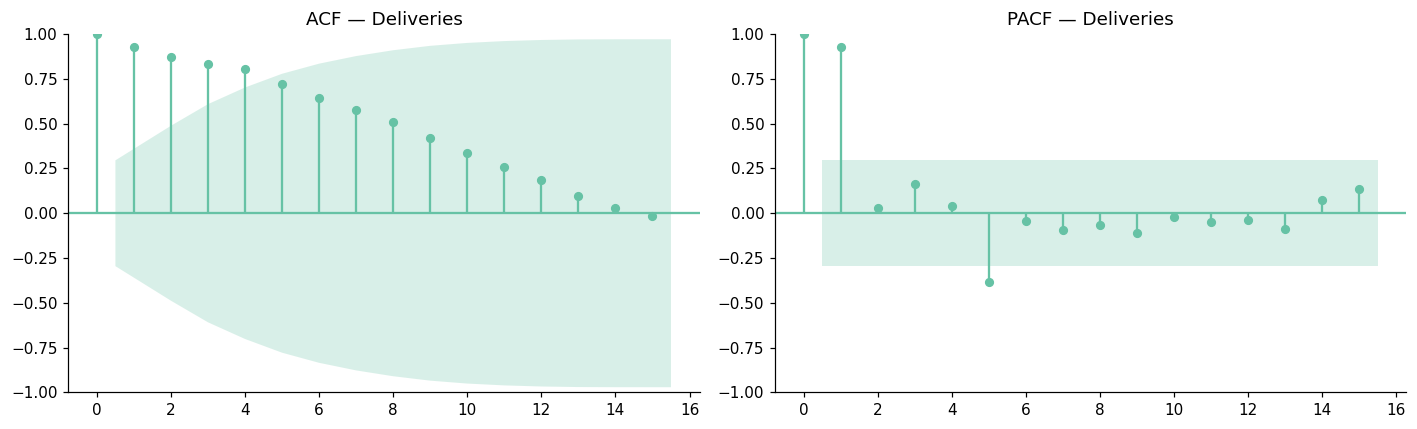

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(deliveries_ts,  lags=15, ax=axes[0], title='ACF — Deliveries')
plot_pacf(deliveries_ts, lags=15, ax=axes[1], title='PACF — Deliveries')
plt.tight_layout()
plt.show()


In [16]:

HOLDOUT = 4
ts_train = deliveries_ts[:-HOLDOUT]
ts_test  = deliveries_ts[-HOLDOUT:]
forecast_horizon = HOLDOUT + 4  # 4 known + 4 future quarters

print(f"Training periods: {len(ts_train)}  |  Test periods: {len(ts_test)}")


Training periods: 40  |  Test periods: 4


In [17]:
ets_model = ExponentialSmoothing(
    ts_train, trend='add', seasonal='add', seasonal_periods=4, damped_trend=True
).fit(optimized=True)

ets_forecast  = ets_model.forecast(forecast_horizon)
ets_test_pred = ets_forecast[:HOLDOUT]

ets_rmse = np.sqrt(mean_squared_error(ts_test, ets_test_pred))
ets_mape = np.mean(np.abs((ts_test - ets_test_pred) / ts_test)) * 100
print(f"ETS → RMSE: {ets_rmse:,.0f}  |  MAPE: {ets_mape:.2f}%")


ETS → RMSE: 115,877  |  MAPE: 28.79%


In [18]:

try:
    arima_model = ARIMA(ts_train, order=(1,1,1), seasonal_order=(1,1,0,4)).fit()
    arima_forecast = arima_model.forecast(steps=forecast_horizon)
    arima_test_pred = arima_forecast[:HOLDOUT]
    arima_rmse = np.sqrt(mean_squared_error(ts_test, arima_test_pred))
    arima_mape = np.mean(np.abs((ts_test - arima_test_pred) / ts_test)) * 100
    print(f"SARIMA → RMSE: {arima_rmse:,.0f}  |  MAPE: {arima_mape:.2f}%")
except Exception as e:
    print(f"ARIMA warning: {e}")
    arima_forecast = ets_forecast  # fallback
    arima_test_pred = ets_test_pred
    arima_rmse = ets_rmse
    arima_mape = ets_mape


SARIMA → RMSE: 126,267  |  MAPE: 31.36%


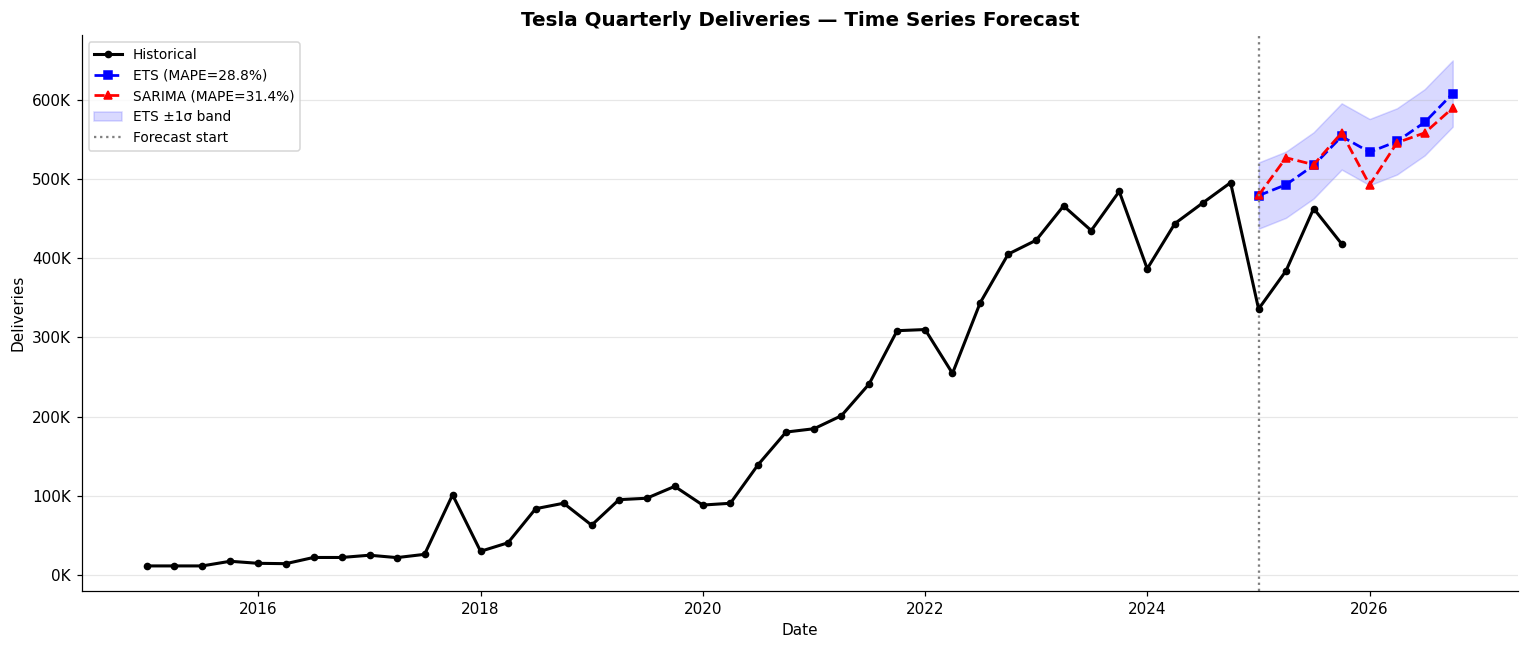

In [19]:
future_dates = pd.date_range(ts_test.index[-1], periods=5, freq='QS')[1:]
all_future   = ts_test.index.tolist() + future_dates.tolist()

fig, ax = plt.subplots(figsize=(14, 6))


ax.plot(deliveries_ts.index, deliveries_ts.values, 'ko-', ms=4, lw=2, label='Historical', zorder=5)

ets_full_dates = list(ts_test.index) + list(future_dates)
ets_full_vals  = list(ets_forecast[:HOLDOUT]) + list(ets_forecast[HOLDOUT:])
ax.plot(ets_full_dates, ets_full_vals, 'b--s', ms=5, lw=1.8, label=f'ETS (MAPE={ets_mape:.1f}%)')

arima_full_dates = ets_full_dates
arima_full_vals  = list(arima_test_pred) + list(arima_forecast[HOLDOUT:])
ax.plot(arima_full_dates, arima_full_vals, 'r--^', ms=5, lw=1.8, label=f'SARIMA (MAPE={arima_mape:.1f}%)')

std_band = np.std(ts_train) * 0.25
ax.fill_between(ets_full_dates,
                np.array(ets_full_vals)-std_band,
                np.array(ets_full_vals)+std_band,
                alpha=0.15, color='blue', label='ETS ±1σ band')

ax.axvline(ts_test.index[0], color='gray', ls=':', lw=1.5, label='Forecast start')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.set_title('Tesla Quarterly Deliveries — Time Series Forecast', fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Deliveries')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('forecast.png', bbox_inches='tight')
plt.show()


In [20]:
future_labels = [f'{d.year}-Q{d.quarter}' for d in future_dates]
forecast_table = pd.DataFrame({
    'Quarter':          future_labels,
    'ETS_Forecast':     ets_forecast[HOLDOUT:].values.astype(int),
    'SARIMA_Forecast':  arima_forecast[HOLDOUT:].astype(int),
})
forecast_table['Avg_Forecast'] = ((forecast_table['ETS_Forecast'] + forecast_table['SARIMA_Forecast']) / 2).astype(int)
print("=== 2026 Delivery Forecast ===")
print(forecast_table.to_string(index=False))


=== 2026 Delivery Forecast ===
Quarter  ETS_Forecast  SARIMA_Forecast  Avg_Forecast
2026-Q1        534138           492721        513429
2026-Q2        547660           546081        546870
2026-Q3        571796           558421        565108
2026-Q4        608059           589826        598942


## 7. Summary

In [21]:
print("=" * 65)
print("   TESLA ML PIPELINE — SUMMARY REPORT")
print("=" * 65)

print("\n📊 DATASET")
print(f"  Quarterly records : {len(df)}")
print(f"  Time span         : 2015-Q1 → 2025-Q4")
print(f"  Key features      : Production, Revenue, Stock Price, Model Mix")

print("\n🔍 EDA INSIGHTS")
print("  - Production & deliveries grew ~40x from 2015 to 2025")
print("  - Model 3/Y became >90% of volume by 2020")
print("  - Revenue per delivery declined slightly (mass-market shift)")
print("  - Strong positive correlation: Production ↔ Deliveries (r=0.99)")

print("\n🤖 REGRESSION (test R²)")
for name, res in results.items():
    print(f"  {name:<30} R²={res['R²']:.4f}  RMSE={res['RMSE']:>10,.0f}")

print(f"\n🔧 TUNED RANDOM FOREST")
print(f"  Best params: {rf_grid.best_params_}")
print(f"  Test R²    : {r2_score(y_test, preds_best):.4f}")
print(f"  Test RMSE  : {np.sqrt(mean_squared_error(y_test, preds_best)):,.0f}")

print(f"\n📈 TIME SERIES FORECAST (2025 holdout)")
print(f"  ETS    MAPE: {ets_mape:.2f}%   RMSE: {ets_rmse:,.0f}")
print(f"  SARIMA MAPE: {arima_mape:.2f}%   RMSE: {arima_rmse:,.0f}")

print("\n🚀 2026 DELIVERY FORECAST")
for _, row in forecast_table.iterrows():
    print(f"  {row['Quarter']}  →  ETS: {row['ETS_Forecast']:>7,}  |  SARIMA: {row['SARIMA_Forecast']:>7,}  |  Avg: {row['Avg_Forecast']:>7,}")

print("\n✅ Pipeline complete!")


   TESLA ML PIPELINE — SUMMARY REPORT

📊 DATASET
  Quarterly records : 44
  Time span         : 2015-Q1 → 2025-Q4
  Key features      : Production, Revenue, Stock Price, Model Mix

🔍 EDA INSIGHTS
  - Production & deliveries grew ~40x from 2015 to 2025
  - Model 3/Y became >90% of volume by 2020
  - Revenue per delivery declined slightly (mass-market shift)
  - Strong positive correlation: Production ↔ Deliveries (r=0.99)

🤖 REGRESSION (test R²)
  Linear Regression              R²=-0.0410  RMSE=    50,857
  Ridge (α=10)                   R²=0.4379  RMSE=    37,373
  Lasso (α=10)                   R²=0.3221  RMSE=    41,041
  Random Forest                  R²=0.5530  RMSE=    33,326
  Gradient Boosting              R²=0.4484  RMSE=    37,021

🔧 TUNED RANDOM FOREST
  Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  Test R²    : 0.5332
  Test RMSE  : 34,056

📈 TIME SERIES FORECAST (2025 holdout)
  ETS    MAPE: 28.79%   RMSE: 115,877
  SARIMA MAPE: 31.36%   RM